# 05 - Stress scenarios - Task 14.6

Drive the portfolio waterfall (Task 14.5, notebook 04) under three named stresses (`spec.md` §9 step 4) and extract the tail-risk numbers Task 14.7 will calibrate against:

1. **Correlated common-factor crash** - many positions, shared market factor with Poisson-Normal crash jumps. Diversification breaks down.
2. **Vol regime shift** - shared GBM path whose annualised vol jumps mid-horizon (`sigma_baseline -> sigma_shock`).
3. **Utilization spike** - same correlated crash, but book scaled 1x to 10x. Per-MM and per-market exposure-cap input.

Each scenario emits a per-run fund-P&L distribution. The tail helpers (`ruin_probability`, `var_cvar`, `summarise`) collapse that into the calibration inputs for 14.7.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inflexion_quant.portfolio import WaterfallConfig
from inflexion_quant.stress import (
    CorrelatedCrashConfig, VolRegimeShiftConfig,
    correlated_crash, vol_regime_shift, utilization_spike,
    summarise, ruin_probability, var_cvar,
)

WATERFALL_CFG = WaterfallConfig(c=0.10, premium_rate_of_maxil=0.75, premium_share_to_fund=0.20)
N_RUNS = 500
N_POSITIONS = 200
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})

## A. Scenario 1 - correlated crash (moderate vs severe)

Two presets bracket realistic stress:

- `moderate()`: ~2 crashes / yr, mean -15% / crash, sigma_idio=30%. Background.
- `severe()`: ~12 crashes / yr (~1 per 30-day horizon), mean -35% / crash, sigma_idio=40%. The 99th-percentile correlated stress.

In [2]:
moderate = correlated_crash(
    n_runs=N_RUNS, n_positions=N_POSITIONS,
    waterfall_cfg=WATERFALL_CFG, rng=np.random.default_rng(20260527),
    cfg=CorrelatedCrashConfig.moderate(),
)
severe = correlated_crash(
    n_runs=N_RUNS, n_positions=N_POSITIONS,
    waterfall_cfg=WATERFALL_CFG, rng=np.random.default_rng(20260527),
    cfg=CorrelatedCrashConfig.severe(),
)

print('--- Correlated crash | Moderate ---')
for k, v in summarise(moderate).items():
    print(f'  {k:>10}: {v:>14,.2f}')
print('\n--- Correlated crash | Severe ---')
for k, v in summarise(severe).items():
    print(f'  {k:>10}: {v:>14,.2f}')

--- Correlated crash | Moderate ---
      n_runs:         500.00
        mean:      36,633.41
         std:       9,945.52
         min:      18,544.55
          p1:      23,022.51
          p5:      25,077.55
         p50:      34,605.13
         p95:      55,481.57
         p99:      68,580.54
         max:     106,195.12
      ruin_p:           0.00
      var_99:     -23,022.51
     cvar_99:     -21,305.08

--- Correlated crash | Severe ---
      n_runs:         500.00
        mean:      29,966.78
         std:      12,784.95
         min:     -23,540.54
          p1:        -122.99
          p5:       7,496.53
         p50:      29,907.86
         p95:      50,099.81
         p99:      64,362.35
         max:      75,024.14
      ruin_p:           0.01
      var_99:         122.99
     cvar_99:       7,272.20


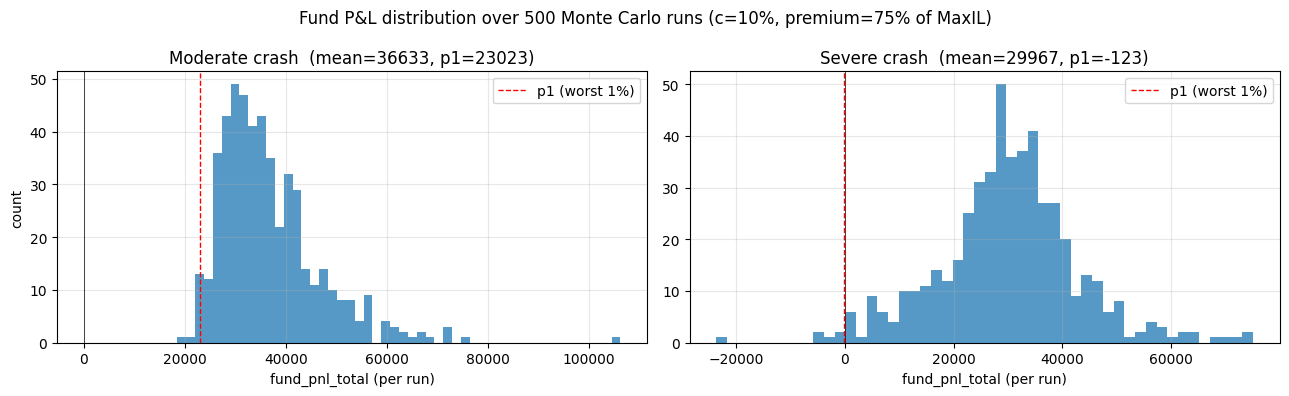

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)
for ax, data, title in [(axes[0], moderate['fund_pnl_total'], 'Moderate crash'), (axes[1], severe['fund_pnl_total'], 'Severe crash')]:
    ax.hist(data, bins=50, alpha=0.75)
    ax.axvline(0, color='k', lw=0.5)
    ax.axvline(data.quantile(0.01), color='red', lw=1, linestyle='--', label='p1 (worst 1%)')
    ax.set_title(f'{title}  (mean={data.mean():.0f}, p1={data.quantile(0.01):.0f})')
    ax.set_xlabel('fund_pnl_total (per run)')
    ax.legend()
axes[0].set_ylabel('count')
plt.suptitle(f'Fund P&L distribution over {N_RUNS} Monte Carlo runs (c=10%, premium=75% of MaxIL)')
plt.tight_layout(); plt.show()

## B. Scenario 2 - vol regime shift

Annualised vol jumps from 30% to a range of post-shock levels at the horizon midpoint. The MM quoted at 30% (mild); the path realises at the shock level. Plot fund_pays_total vs sigma_shock.

In [4]:
shock_grid = np.array([0.30, 0.60, 1.00, 1.50, 2.00, 3.00])
rows = []
for shock in shock_grid:
    out = vol_regime_shift(
        n_runs=N_RUNS, n_positions=N_POSITIONS,
        waterfall_cfg=WATERFALL_CFG, rng=np.random.default_rng(20260527),
        cfg=VolRegimeShiftConfig(sigma_baseline=0.30, sigma_shock=float(shock)),
    )
    s = summarise(out)
    rows.append({'sigma_shock': shock, **s})
vol_sweep = pd.DataFrame(rows)
vol_sweep[['sigma_shock', 'mean', 'p1', 'p5', 'ruin_p', 'var_99', 'cvar_99']]

,sigma_shock,mean,p1,p5,ruin_p,var_99,cvar_99
0,0.3,36282.390892,22201.691863,24747.965045,0.000,-22201.691863,-20550.221154
1,0.6,36221.570162,21747.183206,24546.076273,0.000,-21747.183206,-20354.776363
2,1.0,35698.594285,16486.208597,23950.743235,0.000,-16486.208597,-13487.712045
3,1.5,33899.335562,9337.684717,18278.128087,0.004,-9337.684717,-136.388391
4,2.0,31104.682909,-390.108080,10130.632089,0.012,390.108080,14028.990130
5,3.0,25540.707099,-22660.375349,855.412029,0.050,22660.375349,41608.502260


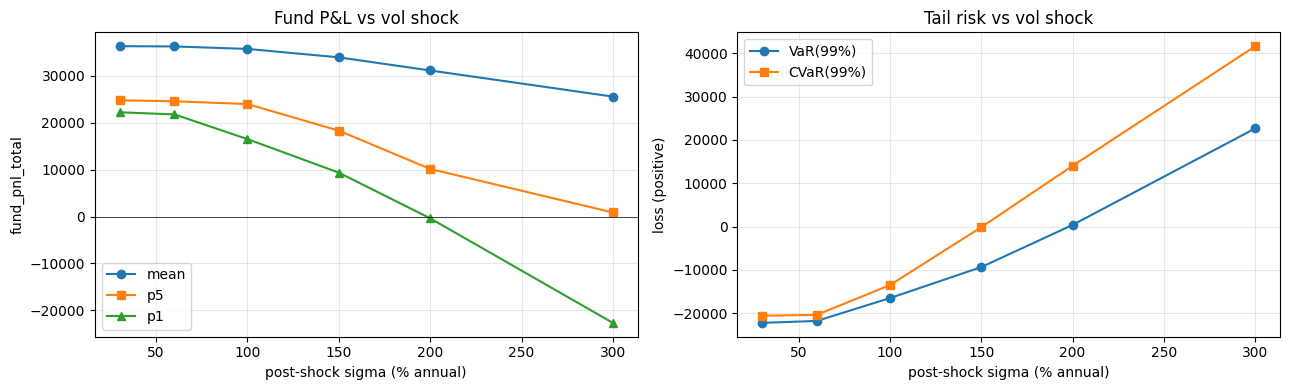

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(vol_sweep['sigma_shock'] * 100, vol_sweep['mean'], marker='o', label='mean')
axes[0].plot(vol_sweep['sigma_shock'] * 100, vol_sweep['p5'], marker='s', label='p5')
axes[0].plot(vol_sweep['sigma_shock'] * 100, vol_sweep['p1'], marker='^', label='p1')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('post-shock sigma (% annual)')
axes[0].set_ylabel('fund_pnl_total')
axes[0].set_title('Fund P&L vs vol shock')
axes[0].legend()
axes[1].plot(vol_sweep['sigma_shock'] * 100, vol_sweep['var_99'], marker='o', label='VaR(99%)')
axes[1].plot(vol_sweep['sigma_shock'] * 100, vol_sweep['cvar_99'], marker='s', label='CVaR(99%)')
axes[1].set_xlabel('post-shock sigma (% annual)')
axes[1].set_ylabel('loss (positive)')
axes[1].set_title('Tail risk vs vol shock')
axes[1].legend()
plt.tight_layout(); plt.show()

## C. Scenario 3 - utilization spike

Same severe correlated crash; sweep book size 1x to 10x. Fund_pays_total scales (roughly) linearly with book; fund equity does not. This is the exposure-cap input for 14.7.

In [6]:
spike_grid = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
rows = []
for mult in spike_grid:
    out = utilization_spike(
        n_runs=200, n_positions_base=100, spike_multiplier=float(mult),
        waterfall_cfg=WATERFALL_CFG, rng=np.random.default_rng(20260527),
        cfg=CorrelatedCrashConfig.severe(),
    )
    s = summarise(out)
    rows.append({'spike_x': mult, 'book_size': int(100 * mult), **s})
util_sweep = pd.DataFrame(rows)
util_sweep[['spike_x', 'book_size', 'mean', 'p1', 'var_99', 'cvar_99']]

,spike_x,book_size,mean,p1,var_99,cvar_99
0,1.0,100,14118.975022,-8848.566419,8848.566419,16459.061136
1,2.0,200,30170.155925,-150.236492,150.236492,3669.260610
2,3.0,300,47439.175429,9910.650497,-9910.650497,-5183.327595
3,5.0,500,75732.665610,5901.568948,-5901.568948,253.122372
4,7.0,700,105311.701069,8018.307236,-8018.307236,12238.249410
5,10.0,1000,141891.667325,18056.310167,-18056.310167,7467.219094


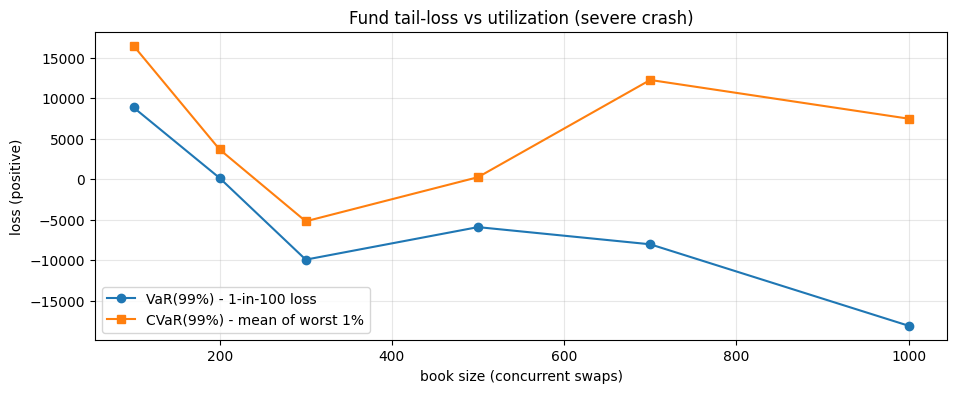

In [7]:
fig, ax = plt.subplots()
ax.plot(util_sweep['book_size'], util_sweep['var_99'], marker='o', label='VaR(99%) - 1-in-100 loss')
ax.plot(util_sweep['book_size'], util_sweep['cvar_99'], marker='s', label='CVaR(99%) - mean of worst 1%')
ax.set_xlabel('book size (concurrent swaps)')
ax.set_ylabel('loss (positive)')
ax.set_title('Fund tail-loss vs utilization (severe crash)')
ax.legend(); plt.show()

## D. Ruin probability vs initial fund balance

For the severe correlated-crash distribution: how much fund equity is needed to keep `P(ruin) <= 0.1%`? This is the **target fund balance** Task 14.7 will fix.

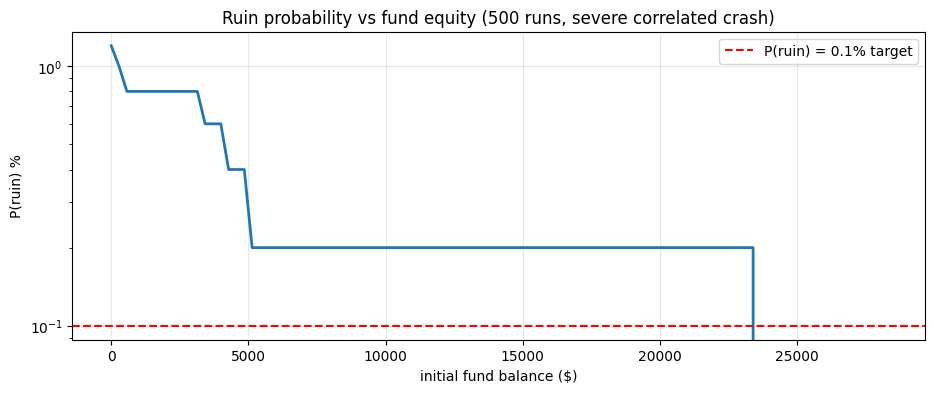

Sample min equity to hit P(ruin)=0 in 500 runs: $23,683
(Statistical caveat: only meaningful up to ~1/N_RUNS = 0.20% resolution)


In [8]:
pnl_severe = severe['fund_pnl_total']
fund_eq_grid = np.linspace(0, max(0, -pnl_severe.min()) * 1.2, 100)
ruin = np.array([ruin_probability(pnl_severe, initial_fund_balance=float(eq)) for eq in fund_eq_grid])

fig, ax = plt.subplots()
ax.plot(fund_eq_grid, ruin * 100, lw=2)
ax.axhline(0.1, color='red', linestyle='--', label='P(ruin) = 0.1% target')
ax.set_xlabel('initial fund balance ($)')
ax.set_ylabel('P(ruin) %')
ax.set_yscale('log')
ax.set_title(f'Ruin probability vs fund equity ({N_RUNS} runs, severe correlated crash)')
ax.legend(); plt.show()

# Smallest equity that drives ruin_p to 0 in our sample
first_zero = fund_eq_grid[np.argmax(ruin == 0)] if (ruin == 0).any() else float('inf')
print(f'Sample min equity to hit P(ruin)=0 in {N_RUNS} runs: ${first_zero:,.0f}')
print(f'(Statistical caveat: only meaningful up to ~1/N_RUNS = {100/N_RUNS:.2f}% resolution)')

## E. Next

**Task 14.7 - Parameter calibration.** Use the distributions above to solve for:

- `c_min` - minimum PARTIAL collateral ratio that keeps `P(ruin) <= 0.1%` under severe crash + median utilization
- `floor_curve(c)` - convex collateral floor as a function of vol regime
- `fee(c)` - convex leverage tax recalibrated so fund inflow covers severe-crash tail
- `circuit-breaker thresholds` (L0/L1/L2/L3) tied to ruin_p quantiles
- `withdrawal-delay` window sized to recovery time after a 99th-pct event
- per-market / per-MM **exposure caps** from the utilization-sweep curves
- MM **first-loss** stake size
- target fund balance for `P(ruin) <= 0.1%`

All eight outputs land in `quant/params.json` (Task 14.8); Phase 15 deploy reads from there with zero hardcoded constants.